In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 31.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.28MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.23MB/s]


In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 12),
            nn.ReLU(True),
            nn.Linear(12, 2)  # 壓縮成 2 維
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 12),
            nn.ReLU(True),
            nn.Linear(12, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 28*28),
            nn.Sigmoid()  # 讓輸出範圍在 [0,1]
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        code = self.encoder(x)
        out = self.decoder(code)
        out = out.view(x.size(0), 1, 28, 28)
        return out, code


In [11]:
torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device(type='cuda')

In [15]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        output, _ = model(img)
        loss = criterion(output, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.0680
Epoch [2/10], Loss: 0.0519
Epoch [3/10], Loss: 0.0473
Epoch [4/10], Loss: 0.0448
Epoch [5/10], Loss: 0.0435
Epoch [6/10], Loss: 0.0424
Epoch [7/10], Loss: 0.0418
Epoch [8/10], Loss: 0.0411
Epoch [9/10], Loss: 0.0406
Epoch [10/10], Loss: 0.0402


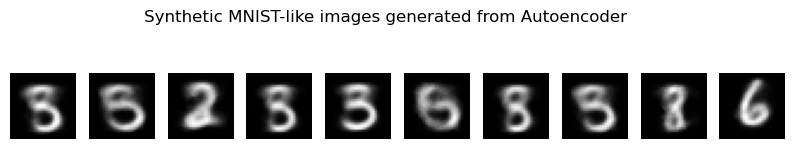

In [8]:
model.eval()
with torch.no_grad():
    # 從隨機2維潛在空間產生10張合成數字
    n = 10
    latent = torch.randn(n, 2).to(device)  # 2維 latent 空間
    synthetic_imgs = model.decoder(latent).view(-1, 1, 28, 28).cpu().numpy()
    
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(synthetic_imgs[i, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle("Synthetic MNIST-like images generated from Autoencoder")
    plt.show()
